# NOTEBOOK: Analyser les ventes d'une librairie avec Python

## PARTIE 1 : Analyse des différents indicateurs de vente

### Importation et chargement des données

In [1]:
#!pip install missingno

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [3]:
#importation des librairies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import plotly.express as px
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr, spearmanr
from scipy.stats import f_oneway


In [4]:
#création des DF customers, products et transactions a partir des fichiers csv de même nom (MAJ du dtype et suppression de lignes de NaN sur transactions.csv)
df_customers= pd.read_csv("customers.csv", sep=';', dtype={'client_id': 'string' , 'sex': 'category'})
df_products= pd.read_csv("products.csv", sep=';', dtype={'id_prod':'string','categ':'category'})
df_transactions= pd.read_csv("transactions.csv", sep=';', low_memory=False, parse_dates=['date'], dtype={'id_prod':'string','session_id':'string', 'client_id':'string'}).dropna(how='all')

### Nettoyage et préparation des données

<Axes: >

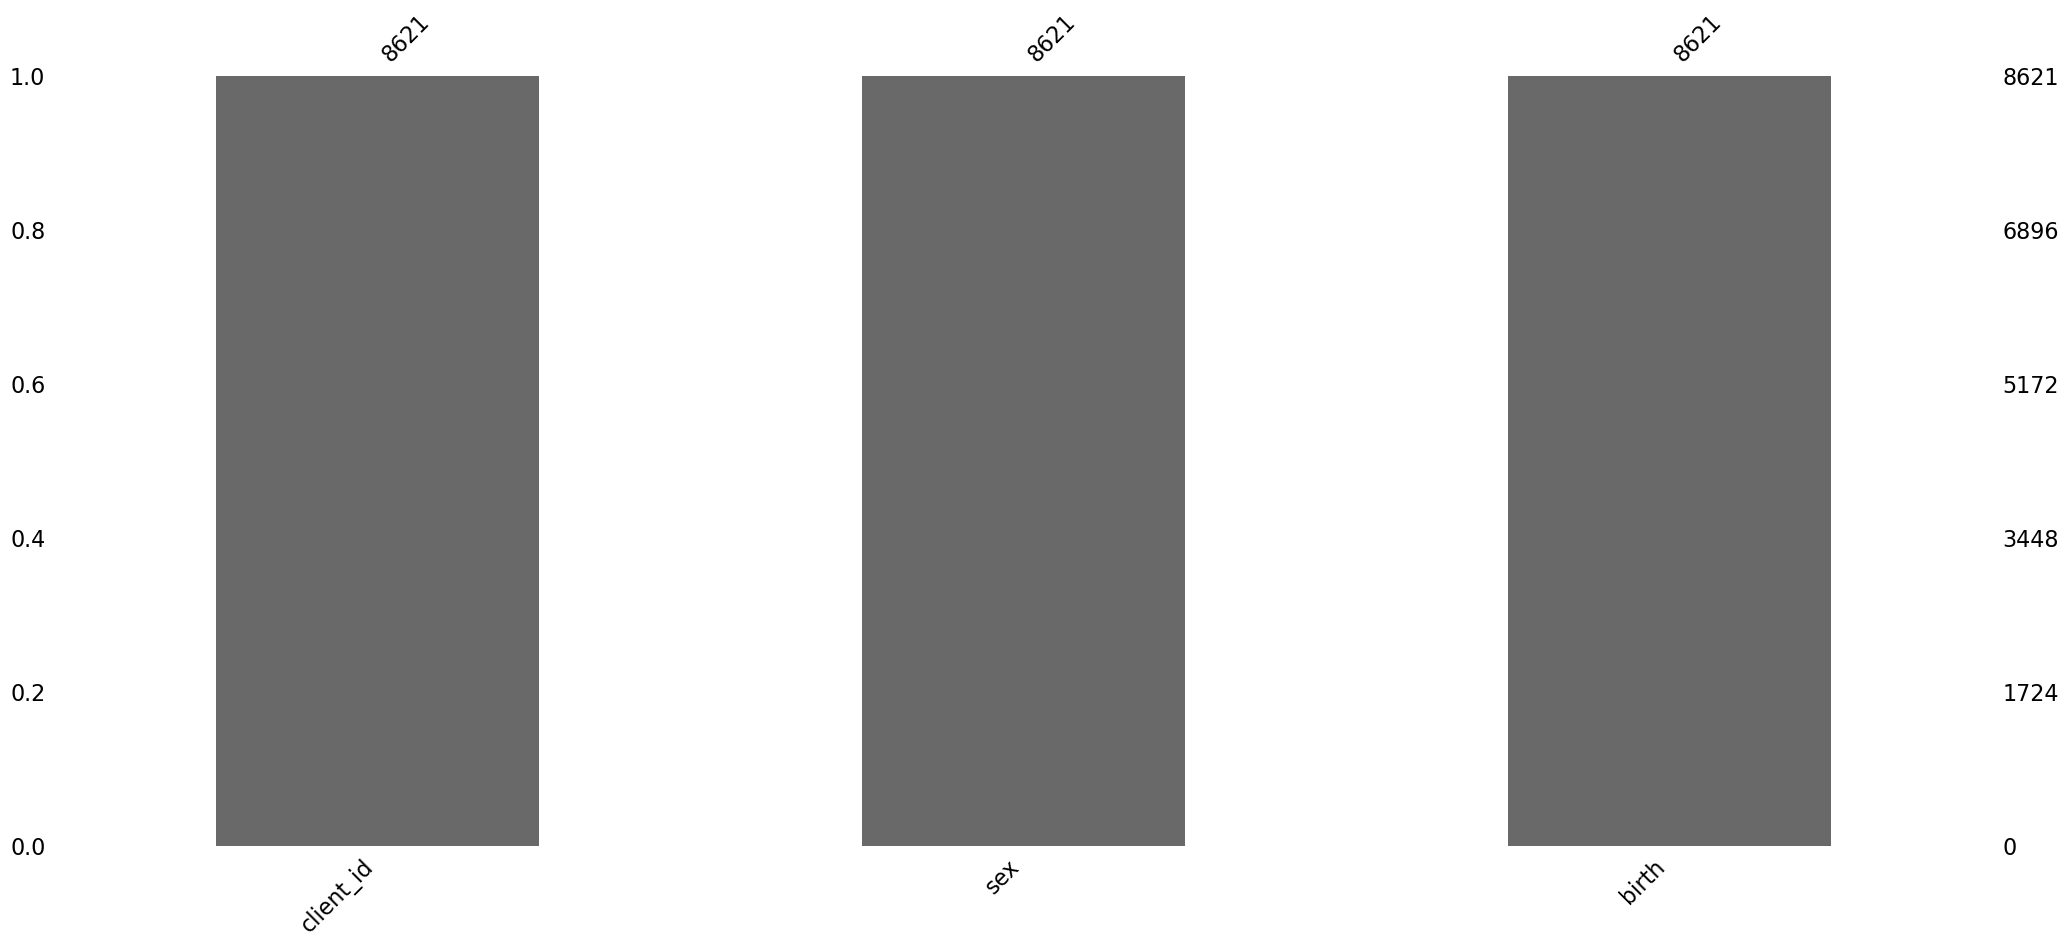

In [5]:
#vérification des données manquantes avec la librairie missingno
msno.bar(df_customers)

<Axes: >

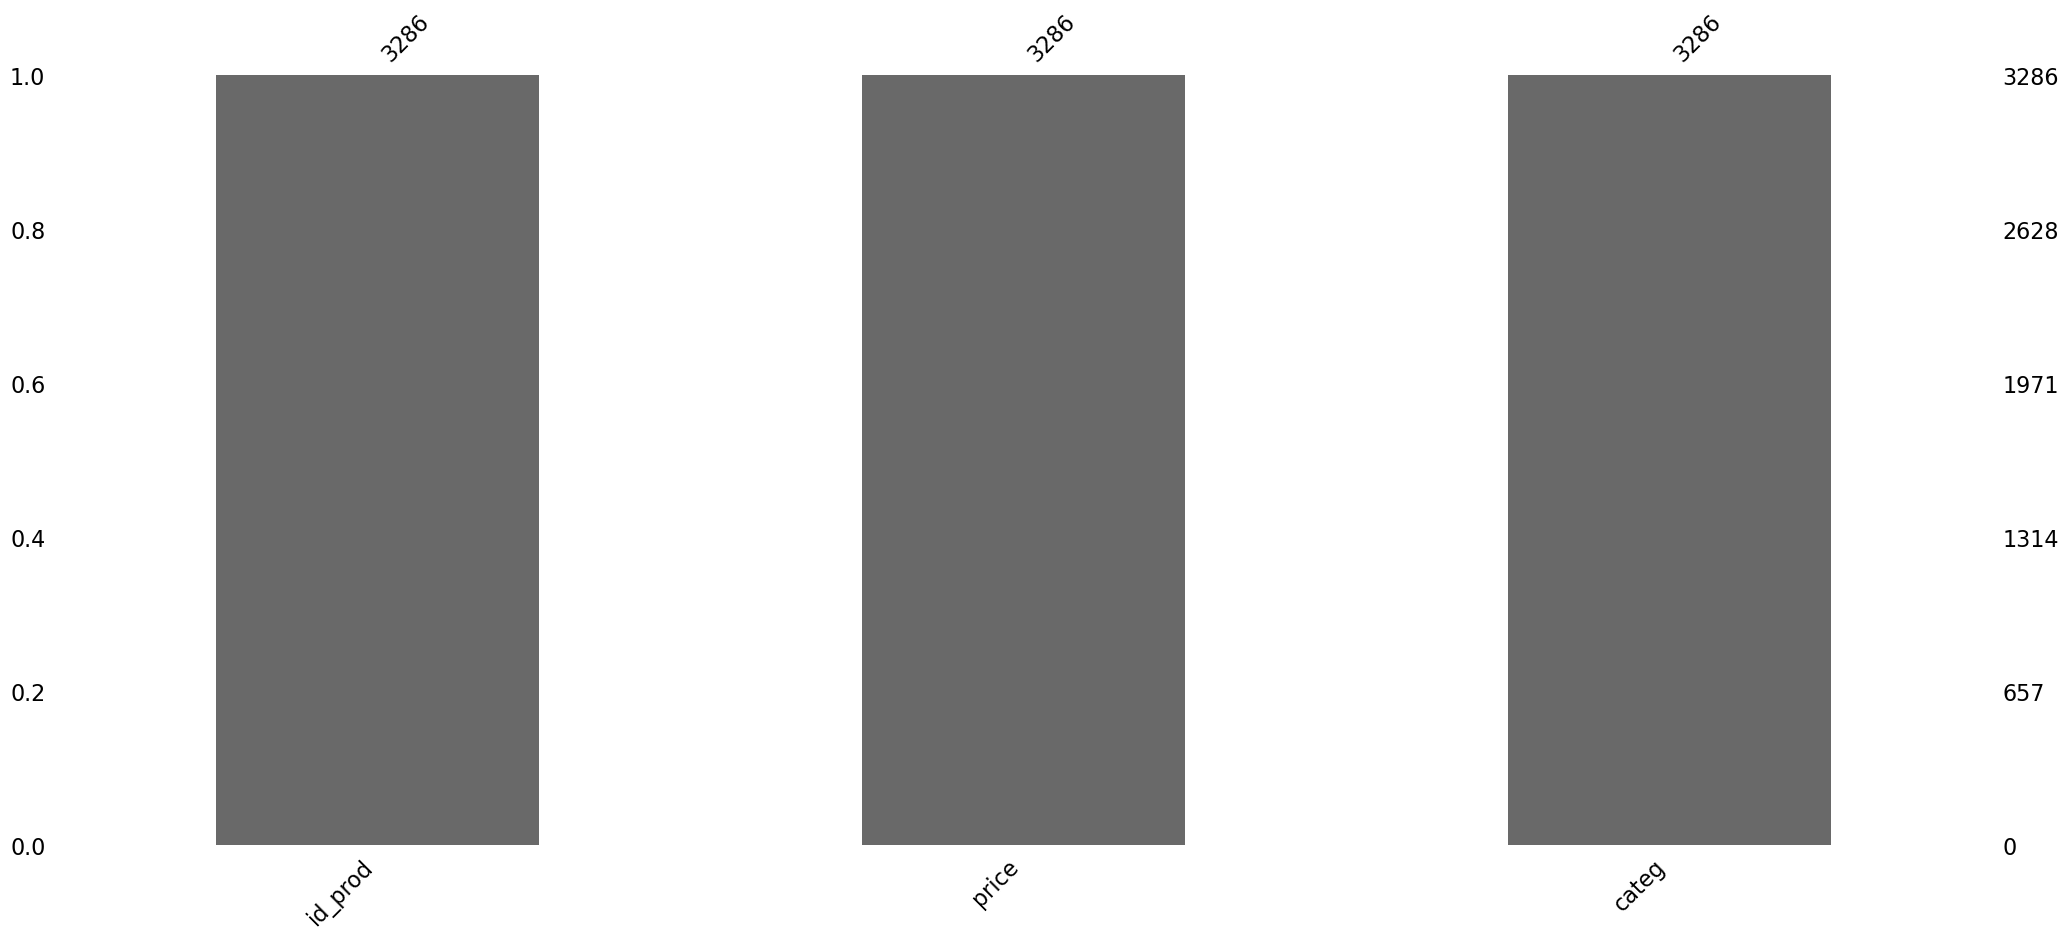

In [6]:
msno.bar(df_products)

<Axes: >

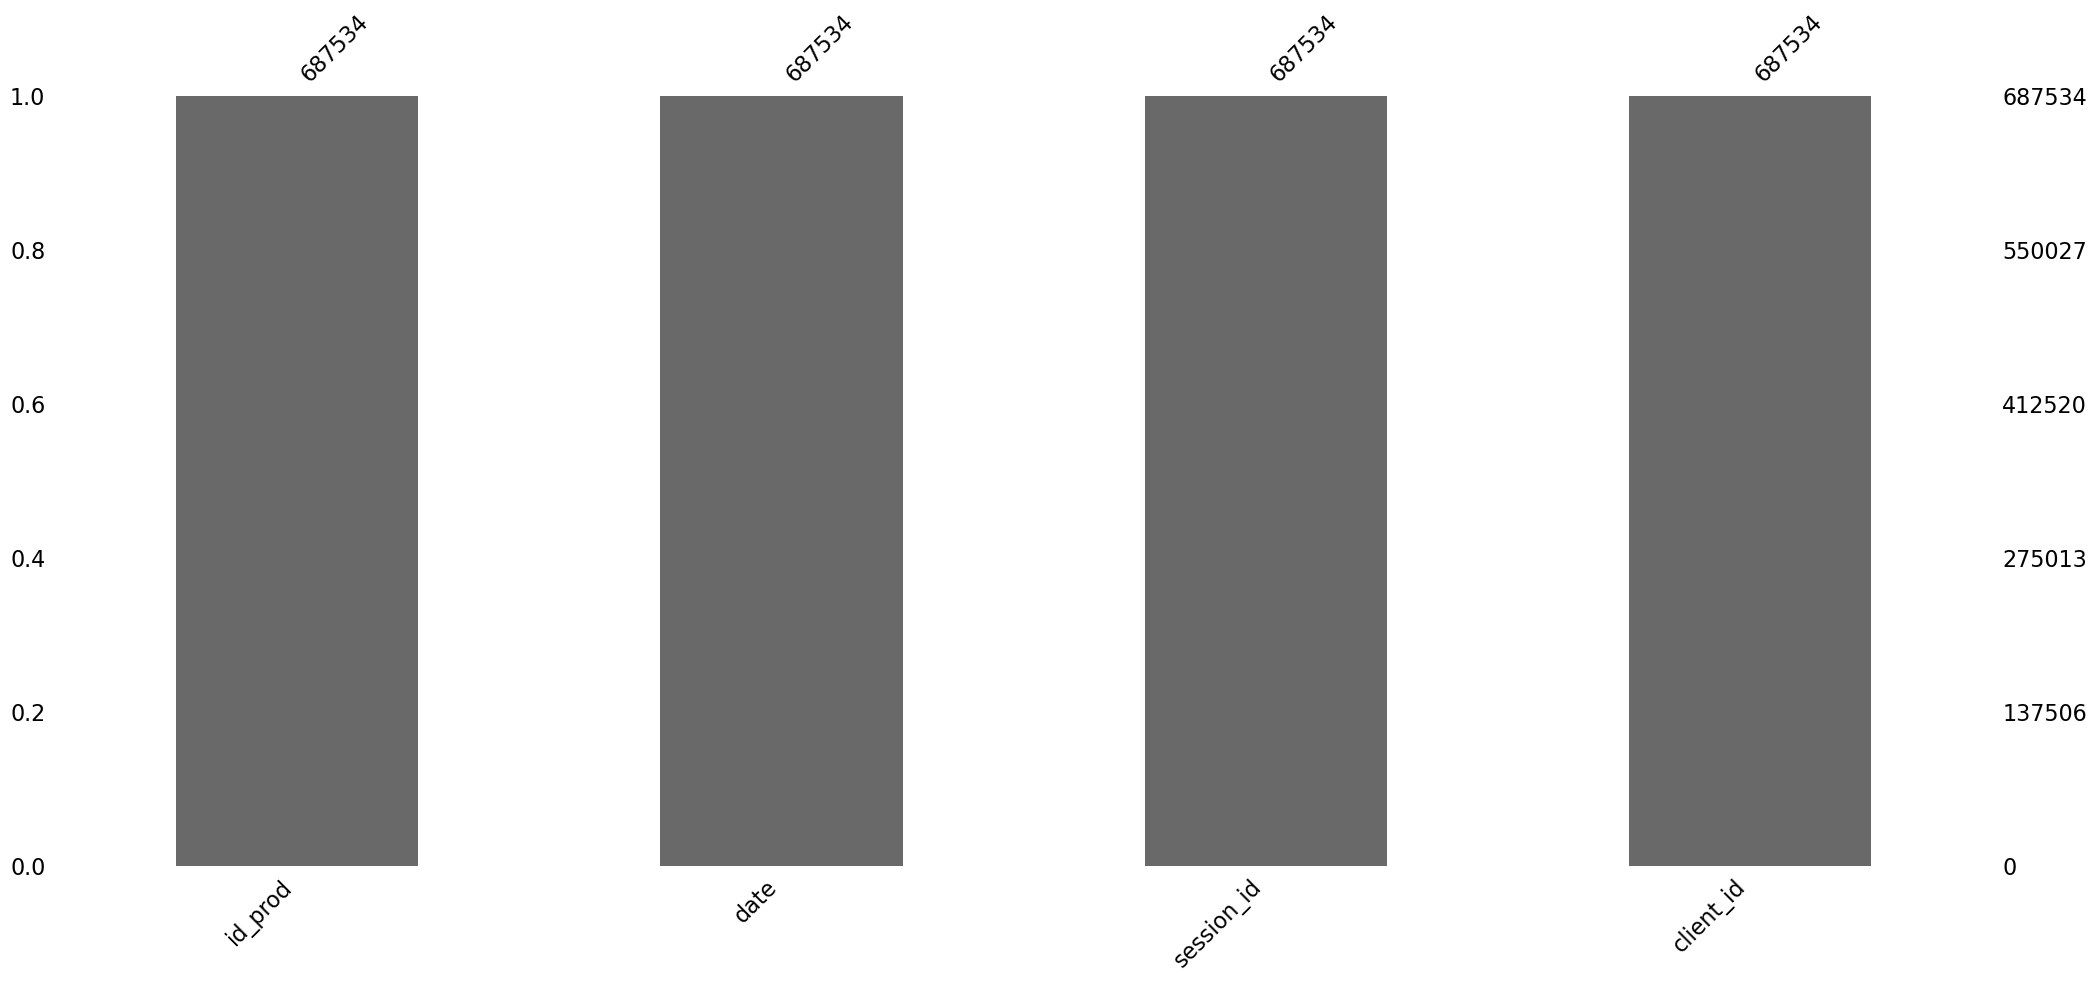

In [7]:
msno.bar(df_transactions)

In [8]:
#recherche de doublons dans les DF customers, products et transactions
print('Il y a {} doublons dans le DataFrame customers'.format(df_customers.duplicated().sum()))
print('Il y a {} doublons dans le DataFrame products'.format(df_products.duplicated().sum()))
print('Il y a {} doublons dans le DataFrame transactions'.format(df_transactions.duplicated().sum()))


Il y a 0 doublons dans le DataFrame customers
Il y a 0 doublons dans le DataFrame products
Il y a 0 doublons dans le DataFrame transactions


In [9]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   client_id  8621 non-null   string  
 1   sex        8621 non-null   category
 2   birth      8621 non-null   int64   
dtypes: category(1), int64(1), string(1)
memory usage: 143.3 KB


In [10]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   id_prod  3286 non-null   string  
 1   price    3286 non-null   float64 
 2   categ    3286 non-null   category
dtypes: category(1), float64(1), string(1)
memory usage: 54.7 KB


In [11]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  string        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  string        
 3   client_id   687534 non-null  string        
dtypes: datetime64[ns](1), string(3)
memory usage: 26.2 MB


##### Les données sont propres (pas de données manquantes, pas de doublons, types de données des variables corrects)donc  place aux jointures 

In [12]:
# Jointure df_transactions + df_products
df_transactions_products = df_transactions.merge(df_products, on='id_prod', how='left', indicator='Merge')
#Verification si données perdues
print(df_transactions_products['Merge'].value_counts())
#Exportation du df_transactions_products en .csv
#df_transactions_products.to_csv("transactions_products.csv", index=False)

Merge
both          687534
left_only          0
right_only         0
Name: count, dtype: int64


##### aucune donnée perdue 

In [13]:
#Jointure df_transactions_products + df_customers
df= df_transactions_products.merge(df_customers, on='client_id', how='left', indicator='Merge_df')

#Vérification des données perdues
print(df['Merge_df'].value_counts())

Merge_df
both          687534
left_only          0
right_only         0
Name: count, dtype: int64


##### aucune donnée perdue 

##### création des variables pour l'analyse et suppression de variables inutiles a l'analyse

In [14]:
# creation variable 'age' 
df['age']= 2023 - df['birth'] 

# création variable 'tranche_age'
# Définir les bornes et labels
bins = [18, 29, 39, 49, 59, 69, 79, 89, 99]  # bornes supérieures incluses
labels = ['19-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90-99']
# Créer la variable tranche_age
df['tranche_age'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# suppression des variables inutiles pour l'analyse: session_id, Merge, Merge_df et birth 
df = df.drop(columns=['session_id', 'Merge', 'Merge_df','birth'])

#Exportation du df en .csv
df.to_csv("df.csv", index=False)

### Statistiques descriptives

In [15]:
# Dimensions du dataset
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

# Aperçu du dataset
df.head()

# Statistiques générales sur les variables 
df.describe()

# Chiffre d'affaires global
ca_total = df["price"].sum()
print(f"Chiffre d'affaires total : {ca_total:.2f} €")

# Prix moyen par transaction
panier_moyen = df["price"].mean()
print(f"Panier moyen : {panier_moyen:.2f} €")

# Nombre de clients uniques
nb_clients = df["client_id"].nunique()
print(f"Nombre de clients uniques : {nb_clients}")

# Nombre total de transactions
nb_transactions = df.shape[0]
print(f"Nombre total de transactions : {nb_transactions}")

# Nombre de produits vendus 
nb_produits = df["id_prod"].nunique()
print(f"Nombre de produits distincts vendus : {nb_produits}")

# Répartition hommes/femmes
print(df["sex"].value_counts(normalize=True) * 100)

# Répartition par tranche d'âge
print(df["tranche_age"].value_counts(normalize=True) * 100)

Nombre de lignes : 687534
Nombre de colonnes : 8
Chiffre d'affaires total : 12027663.10 €
Panier moyen : 17.49 €
Nombre de clients uniques : 8600
Nombre total de transactions : 687534
Nombre de produits distincts vendus : 3265
sex
m    50.15621
f    49.84379
Name: proportion, dtype: float64
tranche_age
40-49    34.048643
30-39    24.187313
50-59    17.193186
19-29    10.345816
60-69     8.441183
70-79     3.901625
80-89     1.699261
90-99     0.182973
Name: proportion, dtype: float64


In [16]:
#Statistiques globales sur les prix des transactions
print(df['price'].describe())

count    687534.000000
mean         17.493918
std          18.238337
min           0.620000
25%           8.990000
50%          13.990000
75%          19.080000
max         300.000000
Name: price, dtype: float64


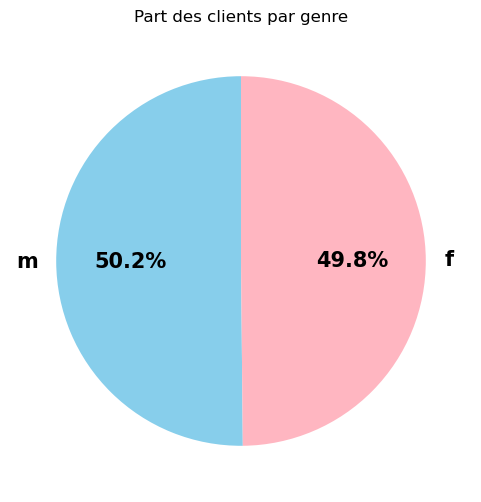

In [17]:
# Répartition par genre
counts_sex = df['sex'].value_counts()
# Visualisation
plt.figure(figsize=(6,6))
plt.pie(counts_sex, 
        labels=counts_sex.index, 
        autopct='%1.1f%%', 
        colors=['skyblue','lightpink'], 
        startangle=90, 
        textprops={'fontsize': 15, 'weight':'bold'})

plt.title("Part des clients par genre")
plt.savefig("repartition_genre.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

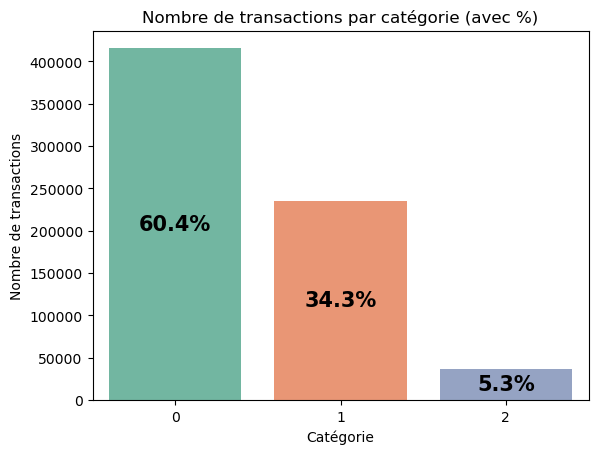

In [18]:
# Répartition par catégorie de produits
counts_categ = df['categ'].value_counts()
total= counts_categ.sum()

#affichage des pourcentages sur les barres
ax = sns.countplot(data=df, x='categ', order=counts_categ.index, hue='categ', palette='Set2')

for p in ax.patches:
    height = p.get_height()
    percent = height / total * 100
    ax.text(p.get_x() + p.get_width()/2, height/2, f"{percent:.1f}%", ha='center', va='center', color='black', fontsize=15, fontweight='bold')

plt.title("Nombre de transactions par catégorie (avec %)")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de transactions")
plt.savefig("transactions_categ.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

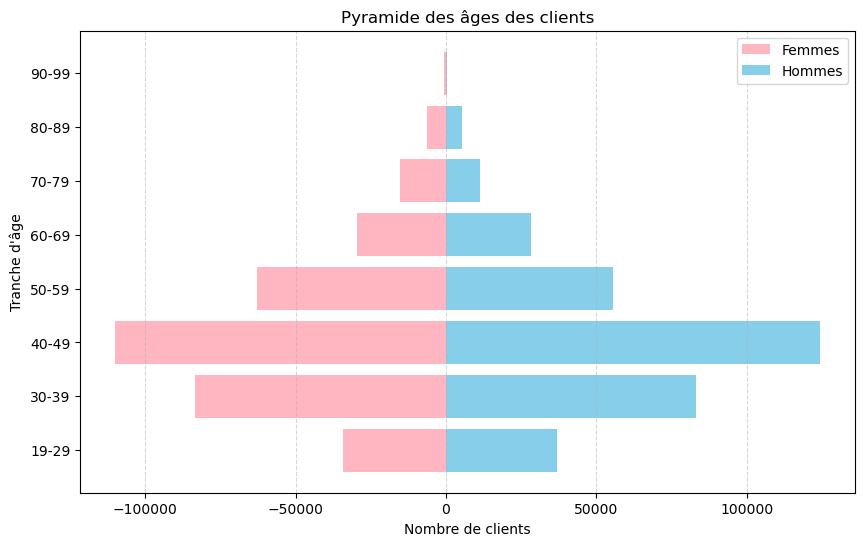

In [19]:
# Calculer le nombre de clients par tranche d'âge et par genre
age_sex_counts = df.groupby(['tranche_age', 'sex'], observed=False).size().unstack(fill_value=0)

# Inverser les valeurs pour les femmes pour l'effet pyramide
age_sex_counts['f'] = -age_sex_counts['f']

# Graphique
plt.figure(figsize=(10,6))
plt.barh(age_sex_counts.index, age_sex_counts['f'], color='lightpink', label='Femmes')
plt.barh(age_sex_counts.index, age_sex_counts['m'], color='skyblue', label='Hommes')

plt.xlabel("Nombre de clients")
plt.ylabel("Tranche d'âge")
plt.title("Pyramide des âges des clients")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

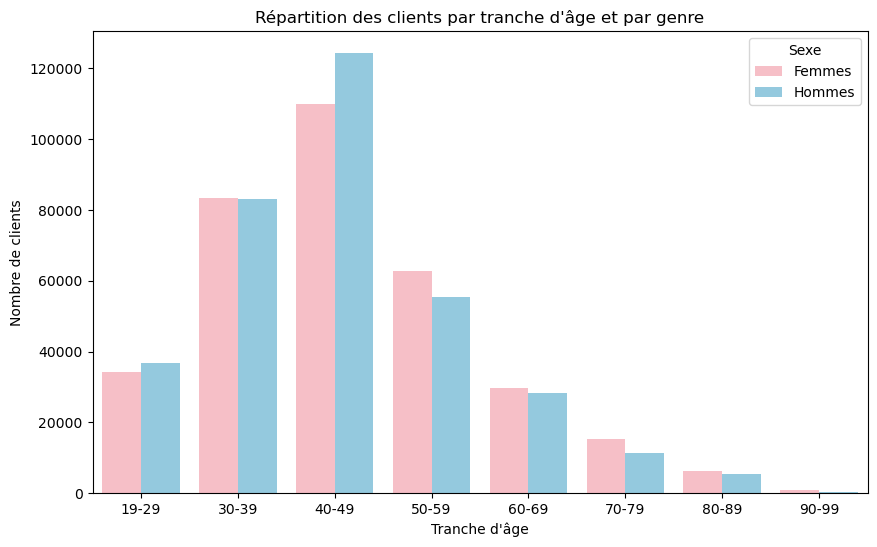

In [20]:
plt.figure(figsize=(10,6))

# Barplot avec hommes et femmes côte à côte
sns.countplot(data=df, x='tranche_age', hue='sex', palette={'m':'skyblue', 'f':'lightpink'})

plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre de clients")
plt.title("Répartition des clients par tranche d'âge et par genre")
plt.legend(title="Sexe", labels=['Femmes', 'Hommes'])
plt.savefig("clients_trancheage.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

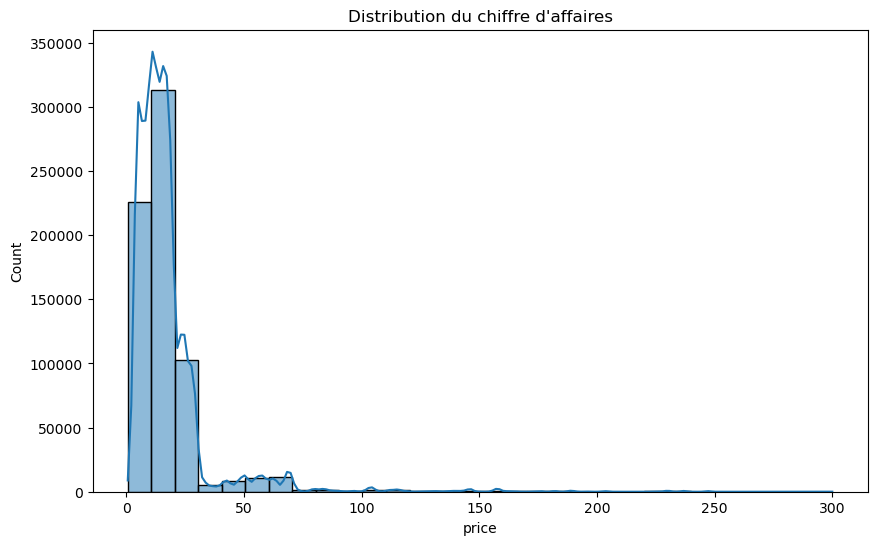

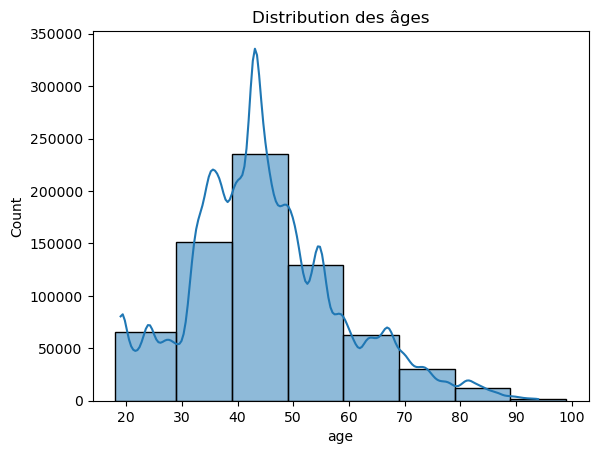

In [21]:
# Histogrammes
plt.figure(figsize=(10,6))

sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution du chiffre d'affaires")
plt.savefig("distrib_ca.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

sns.histplot(df['age'], bins=bins, kde=True)
plt.title("Distribution des âges")
plt.savefig("distrib_age.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

### Analyse temporelle

In [22]:
df['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 687534 entries, 0 to 687533
Series name: date
Non-Null Count   Dtype         
--------------   -----         
687534 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 5.2 MB


##### df['date'] est de type datetime, je peux commencer l'analyse 

##### Evolution du CA par mois avec moyenne mobile

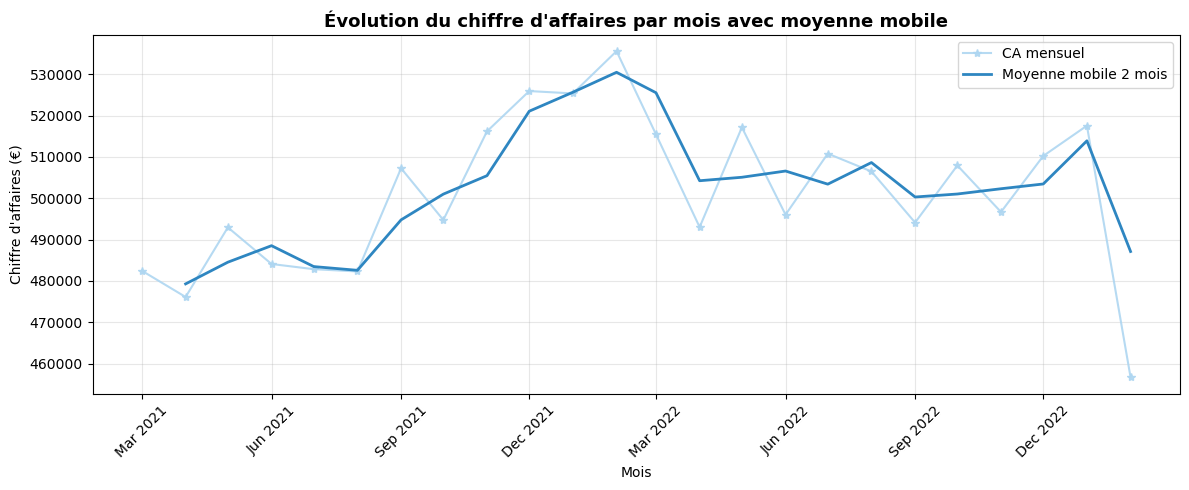

In [23]:
ca_par_mois = df.groupby(df['date'].dt.to_period('M'))['price'].sum()
ca_par_mois.index = ca_par_mois.index.to_timestamp()

# Moyenne mobile sur 2 mois
ca_par_mois_mm = ca_par_mois.rolling(window=2).mean()

# Création des labels mois-année
labels_mois = [d.strftime('%b %Y') for d in ca_par_mois.index]  

plt.figure(figsize=(12,5))
plt.plot(ca_par_mois.index, ca_par_mois.values, marker='*', color='#AED6F1', alpha=0.9, label='CA mensuel')
plt.plot(ca_par_mois_mm.index, ca_par_mois_mm.values, color='#2E86C1', linewidth=2, label='Moyenne mobile 2 mois')
plt.title("Évolution du chiffre d'affaires par mois avec moyenne mobile", fontsize=13, fontweight='bold')
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(ca_par_mois.index[::3], [labels_mois[i] for i in range(0, len(labels_mois), 3)], rotation=45)  

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evol_ca_mm.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

##### CA par catégorie par mois

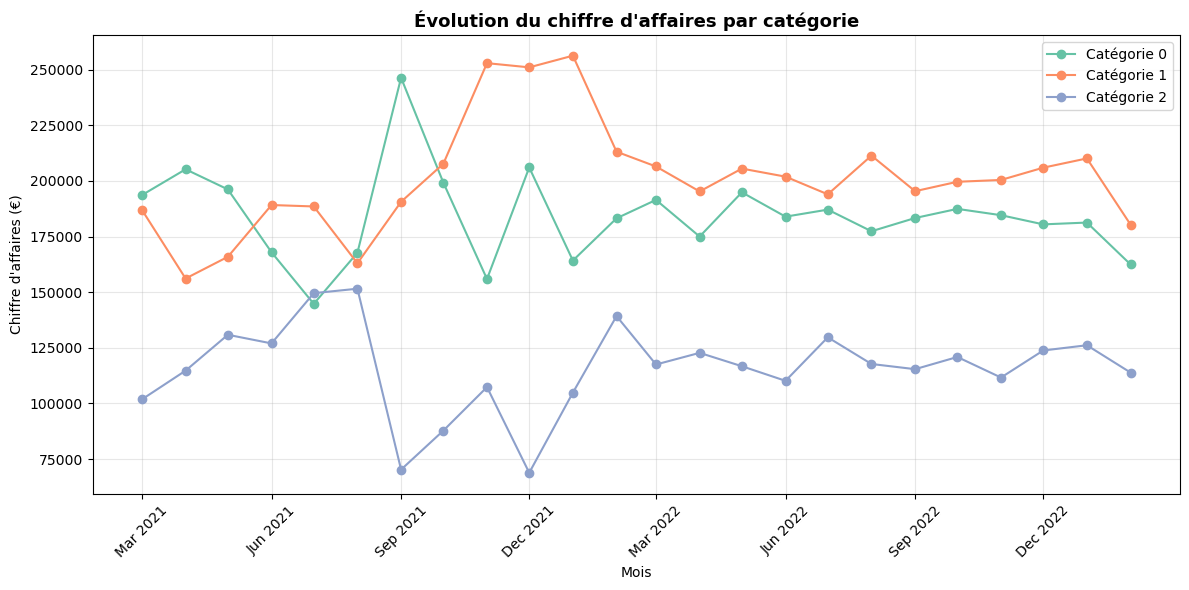

In [24]:
# Regrouper le CA par mois et par catégorie
ca_par_mois_categ = df.groupby([df['date'].dt.to_period('M'), 'categ'], observed=False)['price'].sum().unstack()

# Création des labels mois-année
labels_mois = [d.strftime('%b %Y') for d in ca_par_mois_categ.index.to_timestamp()]

plt.figure(figsize=(12,6))

# Tracer une courbe pour chaque catégorie
colors = ['#66c2a5','#fc8d62','#8da0cb']  
for i, col in enumerate(ca_par_mois_categ.columns):
    plt.plot(ca_par_mois_categ.index.to_timestamp(), ca_par_mois_categ[col], marker='o', label=f'Catégorie {col}', color=colors[i])

plt.title("Évolution du chiffre d'affaires par catégorie", fontsize=13, fontweight='bold')
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(ca_par_mois_categ.index.to_timestamp()[::3], labels_mois[::3], rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evol_ca_cat.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

##### Comparaison CA/nombre de clients VS CA/panier moyen 

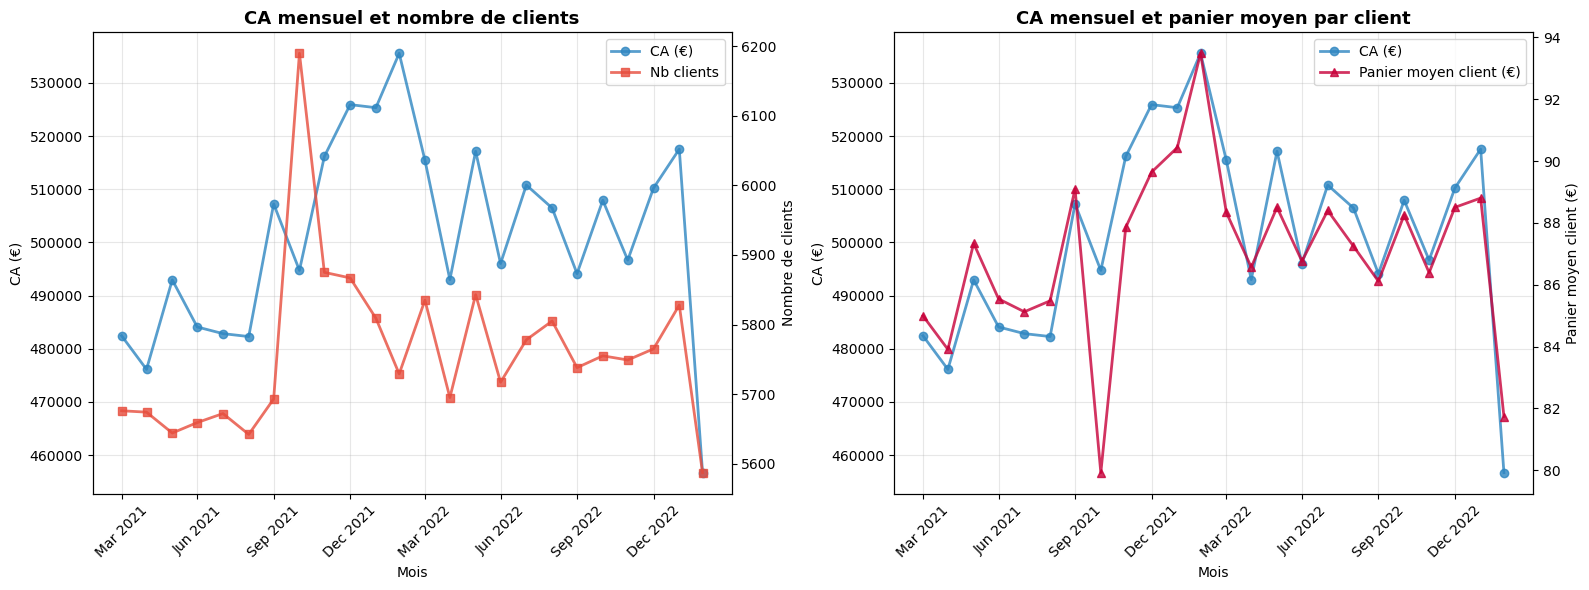

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#CA mensuel & nombre de clients
ca_par_mois = df.groupby(pd.Grouper(key='date', freq='M'))['price'].sum().sort_index()
clients_par_mois = df.groupby(pd.Grouper(key='date', freq='M'))['client_id'].nunique().sort_index()

# Labels pour l’axe X
labels_mois = [d.strftime('%b %Y') for d in ca_par_mois.index]

# CA mensuel / Nombre de clients
ax1 = axes[0]
ax2 = ax1.twinx()

ax1.plot(ca_par_mois.index, ca_par_mois.values, marker='o', color='#2E86C1',
         linewidth=2, alpha=0.8, label='CA (€)')
ax2.plot(clients_par_mois.index, clients_par_mois.values, marker='s', color='#E74C3C',
         linewidth=2, alpha=0.8, label='Nb clients')

ax1.set_title("CA mensuel et nombre de clients", fontsize=13, fontweight='bold')
ax1.set_xlabel("Mois")
ax1.set_ylabel("CA (€)")
ax2.set_ylabel("Nombre de clients")

ax1.set_xticks(ca_par_mois.index[::3])  # un tick tous les 3 mois
ax1.set_xticklabels(labels_mois[::3], rotation=45)
ax1.grid(alpha=0.3)

# Légendes combinées
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')


# CA mensuel et Panier moyen par client

# CA total par client et par mois
ca_client_mois = (
    df.groupby([pd.Grouper(key='date', freq='M'), 'client_id'])['price']
      .sum()
      .reset_index()
)

# Panier moyen par client 
panier_moyen = (
    ca_client_mois.groupby('date')['price']
      .mean()
      .sort_index()
)

# CA mensuel / Panier moyen par client
ax3 = axes[1]
ax4 = ax3.twinx()

ax3.plot(ca_par_mois.index, ca_par_mois.values, marker='o', color='#2E86C1',
         linewidth=2, alpha=0.8, label='CA (€)')
ax4.plot(panier_moyen.index, panier_moyen.values, marker='^', color='#C70039',
         linewidth=2, alpha=0.8, label='Panier moyen client (€)')

ax3.set_title("CA mensuel et panier moyen par client", fontsize=13, fontweight='bold')
ax3.set_xlabel("Mois")
ax3.set_ylabel("CA (€)")
ax4.set_ylabel("Panier moyen client (€)")

ax3.set_xticks(ca_par_mois.index[::3])
ax3.set_xticklabels(labels_mois[::3], rotation=45)
ax3.grid(alpha=0.3)

# Légendes combinées
lines_3, labels_3 = ax3.get_legend_handles_labels()
lines_4, labels_4 = ax4.get_legend_handles_labels()
ax3.legend(lines_3 + lines_4, labels_3 + labels_4, loc='upper right')

# Mise en page & export
plt.tight_layout()
plt.savefig("ca_clients_ca_pm_client.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()


##### Visualisation du nombre de clients uniques et du nombre de transactions

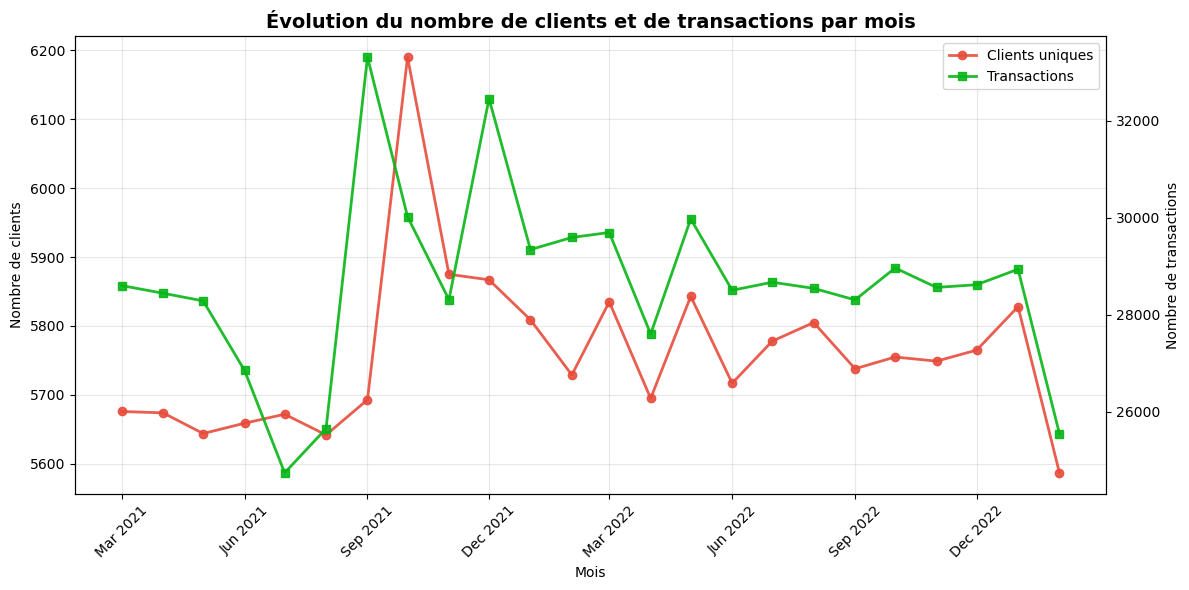

In [26]:
# Nombre de clients uniques par mois
clients_par_mois = df.groupby(df['date'].dt.to_period('M'))['client_id'].nunique()

# Nombre de transactions par mois (nombre de lignes)
transactions_par_mois = df.groupby(df['date'].dt.to_period('M')).size()

# Labels mois-année
labels_mois = [d.strftime('%b %Y') for d in clients_par_mois.index.to_timestamp()]

fig, ax1 = plt.subplots(figsize=(12,6))

# Courbe nombre de clients sur l'axe de gauche
ax1.plot(
    clients_par_mois.index.to_timestamp(), 
    clients_par_mois.values, 
    marker='o', 
    color='#E74C3C',  
    linewidth=2,
    alpha=0.9,
    label='Clients uniques'
)
ax1.set_xlabel("Mois")
ax1.set_ylabel("Nombre de clients", color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Axe secondaire pour les transactions
ax2 = ax1.twinx()
ax2.plot(
    transactions_par_mois.index.to_timestamp(), 
    transactions_par_mois.values, 
    marker='s', 
    color='#07b516',  
    linewidth=2,
    alpha=0.9,
    label='Transactions'
)
ax2.set_ylabel("Nombre de transactions", color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Titre, grid, légende
plt.title("Évolution du nombre de clients et de transactions par mois", fontsize=14, fontweight='bold')
ax1.set_xticks(clients_par_mois.index.to_timestamp()[::3])
ax1.set_xticklabels(labels_mois[::3], rotation=45)
ax1.grid(alpha=0.3)

# Légendes combinées
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.savefig("cli_trans_temps.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

### Analyse des produits

#### CA par catégorie 

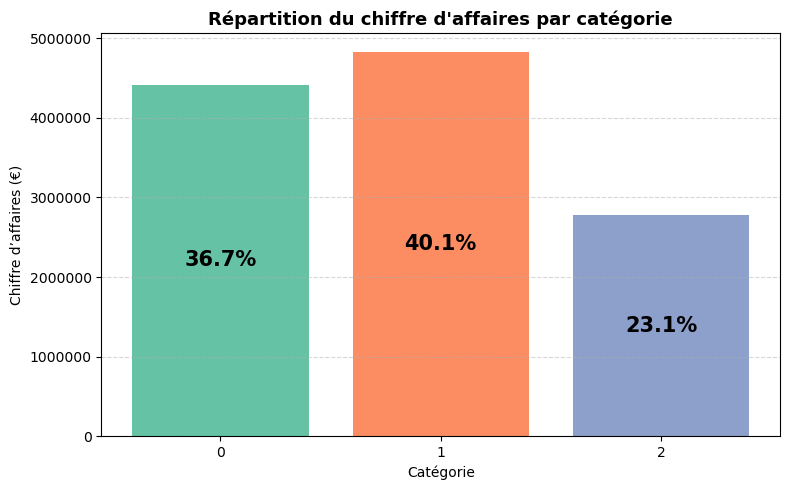

In [27]:
#Répartition du CA par catégorie
# Regrouper le ca par catégorie 
ca_par_categ = df.groupby("categ", observed=False)["price"].sum()

# Calculer les pourcentages
pourcentages = (ca_par_categ / ca_par_categ.sum()) * 100

# Récupérer la palette Set2 du graphique précédent
palette = sns.color_palette("Set2", n_colors=len(ca_par_categ))

# Création du graphique
plt.figure(figsize=(8,5))
bars = plt.bar(ca_par_categ.index.astype(str), ca_par_categ.values, color=palette)

# Ajouter les pourcentages 
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height / 2,  
        f"{pourcentages.iloc[i]:.1f}%",
        ha='center',
        va='center', 
        fontsize=15,
        fontweight='bold',
        color='black'  
    )

# Titre et labels
plt.title("Répartition du chiffre d'affaires par catégorie", fontsize=13, fontweight='bold')
plt.xlabel("Catégorie")
plt.ylabel("Chiffre d’affaires (€)")

# Afficher les valeurs réelles sur l’axe des ordonnées
plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("ca_categ.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#### TOP10

##### selon le CA

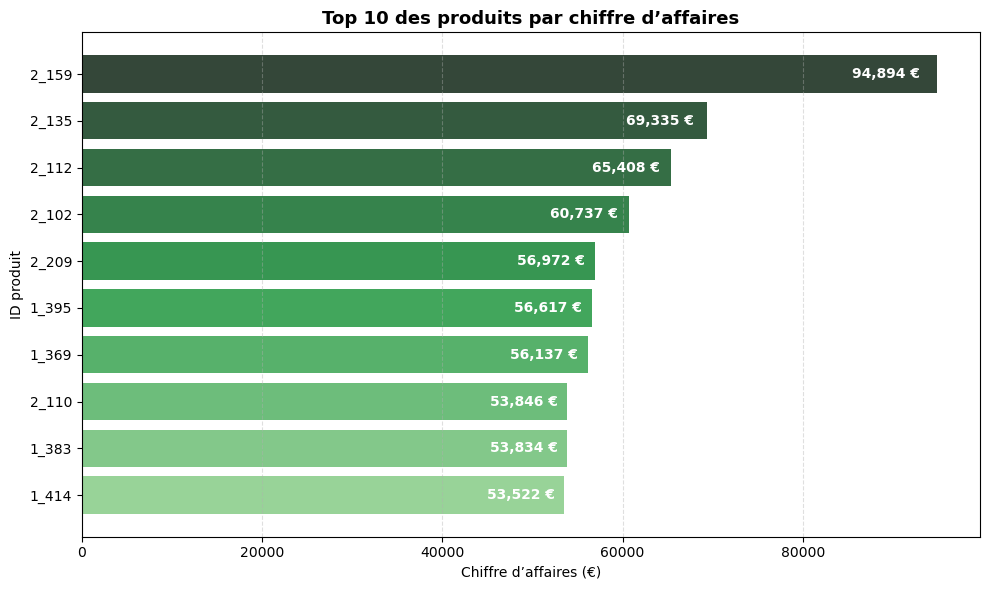

In [28]:
# Top 10 produits par CA
top10_ca = df.groupby('id_prod')['price'].sum().nlargest(10).sort_values()

# Palette de vert dégradé 
colors = sns.color_palette("Greens_d", n_colors=len(top10_ca))

plt.figure(figsize=(10,6))

# Barres horizontales
bars = plt.barh(top10_ca.index, top10_ca.values, color=colors)

# Titre et axes
plt.title("Top 10 des produits par chiffre d’affaires", fontsize=13, fontweight='bold')
plt.xlabel("Chiffre d’affaires (€)")
plt.ylabel("ID produit")
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Ajouter les valeurs à l'intérieur des barres
for bar in bars:
    width = bar.get_width()
    plt.text(width * 0.98,                     
             bar.get_y() + bar.get_height()/2, 
             f"{width:,.0f} €",                 
             ha='right', va='center', color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("top10_ca.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

##### selon les quantités vendues 

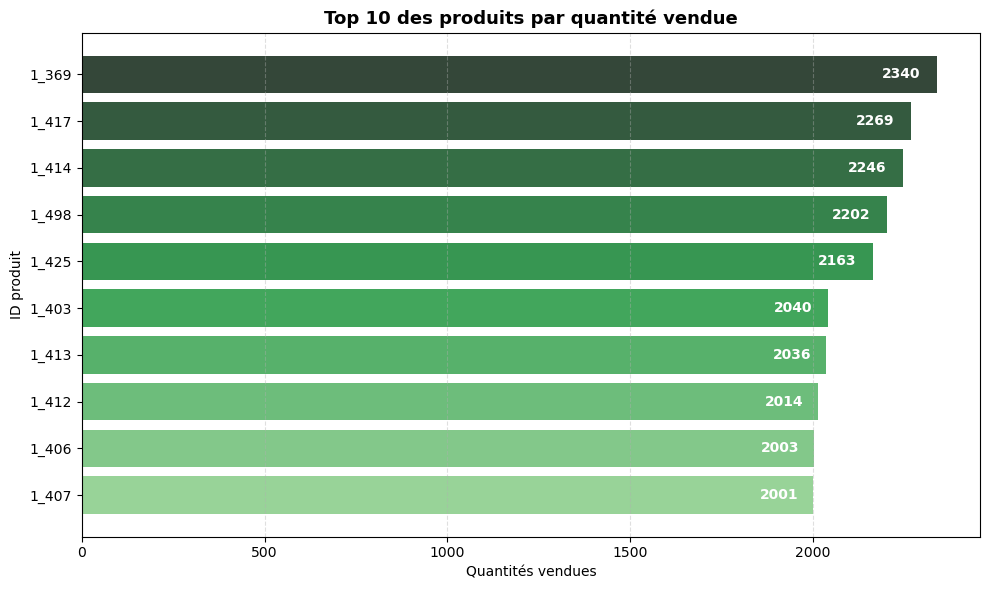

In [29]:
# Calcul du nombre de ventes par produit
top10_qte = df.groupby('id_prod')['id_prod'].count().nlargest(10).sort_values()

# Palette verte dégradée
colors = sns.color_palette("Greens_d", n_colors=len(top10_qte))

plt.figure(figsize=(10,6))
bars = plt.barh(top10_qte.index, top10_qte.values, color=colors)

plt.title("Top 10 des produits par quantité vendue", fontsize=13, fontweight='bold')
plt.xlabel("Quantités vendues")
plt.ylabel("ID produit")
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Ajouter les valeurs à l'intérieur des barres
for bar in bars:
    width = bar.get_width()
    plt.text(width * 0.98,                       
             bar.get_y() + bar.get_height()/2,   
             f"{int(width)}",                    
             ha='right', va='center', 
             color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("top10_qt.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#### FLOP10

##### selon le CA

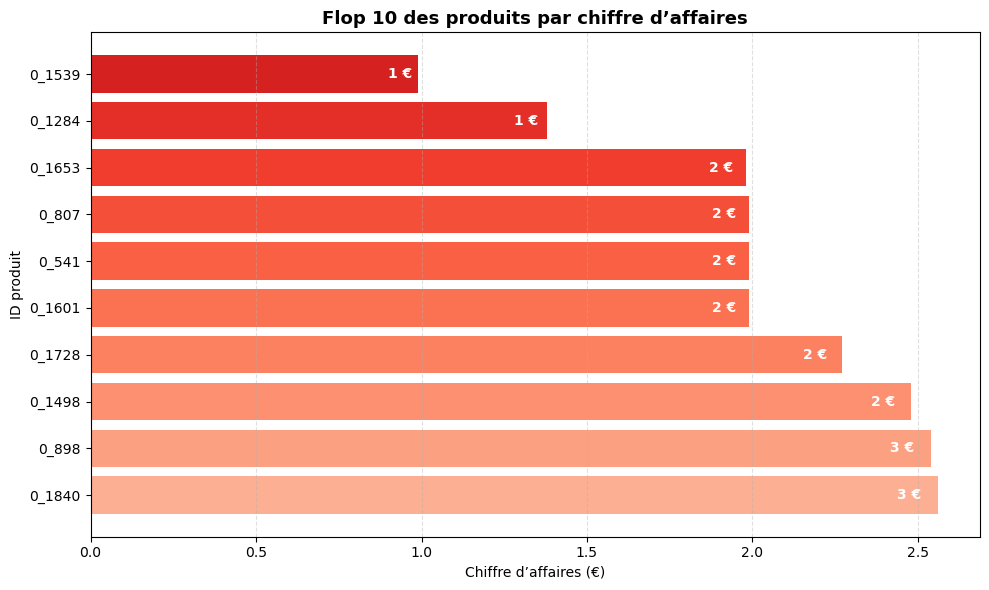

In [30]:
# Calcul du CA par produit
flop10_ca = df.groupby('id_prod')['price'].sum().nsmallest(10).sort_values(ascending=False)

# Palette rouge dégradée
colors = sns.color_palette("Reds", n_colors=20)[5:15]

plt.figure(figsize=(10,6))
bars = plt.barh(flop10_ca.index, flop10_ca.values, color=colors)

plt.title("Flop 10 des produits par chiffre d’affaires", fontsize=13, fontweight='bold')
plt.xlabel("Chiffre d’affaires (€)")
plt.ylabel("ID produit")
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Ajouter les valeurs à l’intérieur des barres
for bar in bars:
    width = bar.get_width()
    plt.text(width * 0.98, 
             bar.get_y() + bar.get_height()/2, 
             f"{width:,.0f} €", 
             ha='right', va='center', 
             color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("flop10_ca.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

##### selon les quantités vendues 

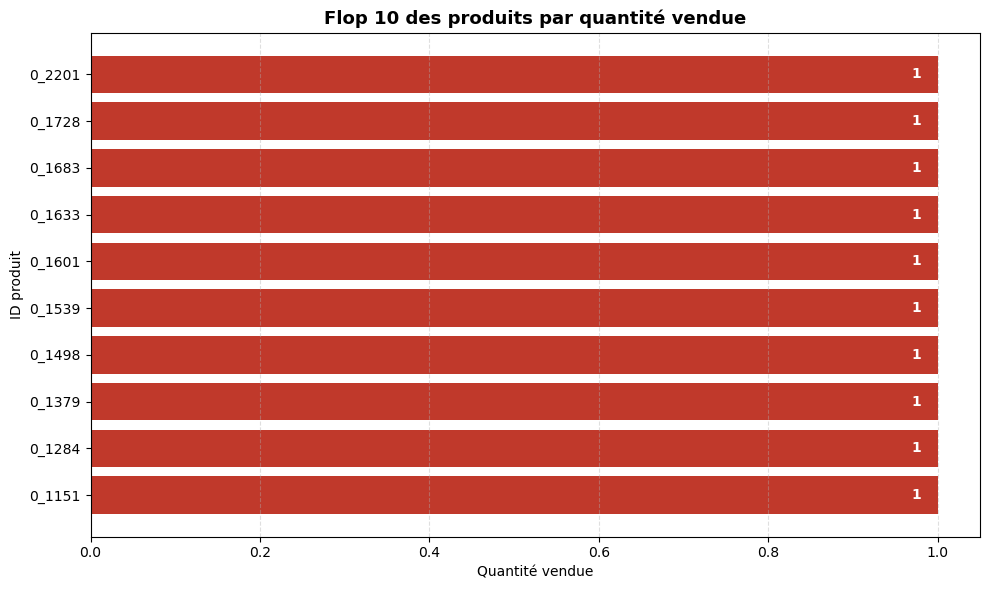

In [31]:
# Calcul du nombre de ventes par produit
flop10_qte = df.groupby('id_prod')['id_prod'].count().nsmallest(10).sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.barh(flop10_qte.index, flop10_qte.values, color='#C0392B')

plt.title("Flop 10 des produits par quantité vendue", fontsize=13, fontweight='bold')
plt.xlabel("Quantité vendue")
plt.ylabel("ID produit")
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Ajouter les valeurs à l’intérieur des barres
for bar in bars:
    width = bar.get_width()
    plt.text(width * 0.98, 
             bar.get_y() + bar.get_height()/2, 
             f"{int(width)}", 
             ha='right', va='center', 
             color='white', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("flop10_qt.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#### evolution dans le temps des TOP 

##### en CA 

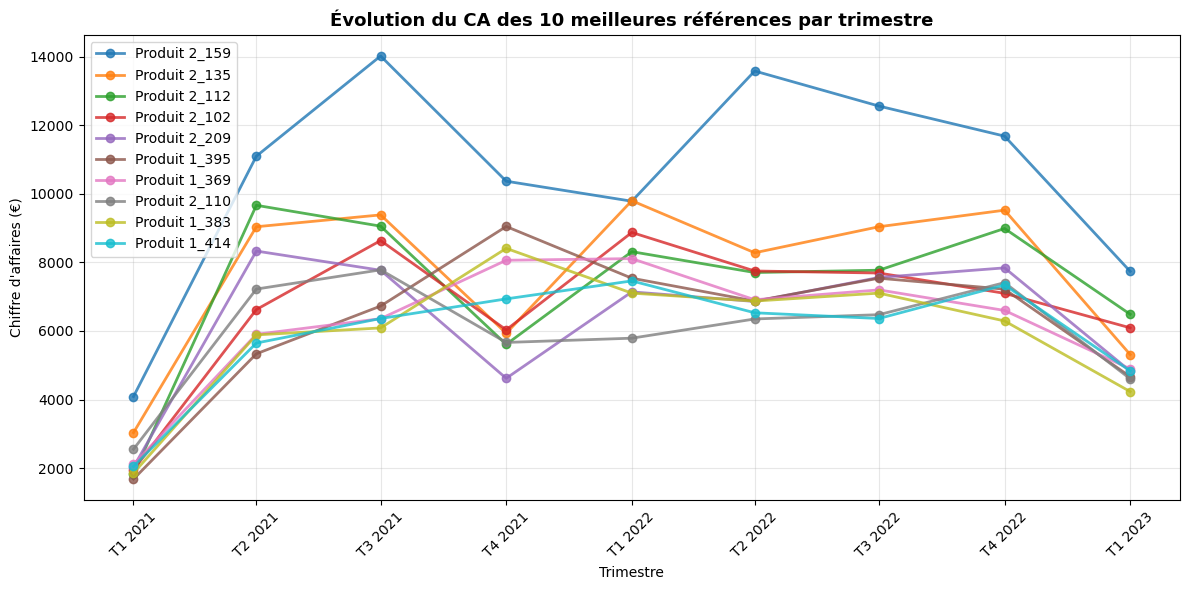

In [32]:
#Regrouper le CA par trimestre et par livre
ca_par_trim_prod = df.groupby([df['date'].dt.to_period('Q'), 'id_prod'])['price'].sum().unstack()

#Sélectionner le top 10 produits selon le CA total
top10_prod_ca = ca_par_trim_prod.sum().sort_values(ascending=False).head(10).index
ca_top10_trim = ca_par_trim_prod[top10_prod_ca]

# Créer les labels trimestre-année
labels_trim = [f"T{d.quarter} {d.year}" for d in ca_top10_trim.index.to_timestamp()]

# Tracer le graphique
plt.figure(figsize=(12,6))
colors = sns.color_palette("tab10", n_colors=10)  # 10 couleurs distinctes pour les 10 produits

for i, prod in enumerate(ca_top10_trim.columns):
    plt.plot(ca_top10_trim.index.to_timestamp(), ca_top10_trim[prod], marker='o', 
             color=colors[i], linewidth=2, alpha=0.8, label=f'Produit {prod}')

plt.title("Évolution du CA des 10 meilleures références par trimestre", fontsize=13, fontweight='bold')
plt.xlabel("Trimestre")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(ca_top10_trim.index.to_timestamp(), labels_trim, rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evol_tps_ca_top10.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()


##### en quantité 

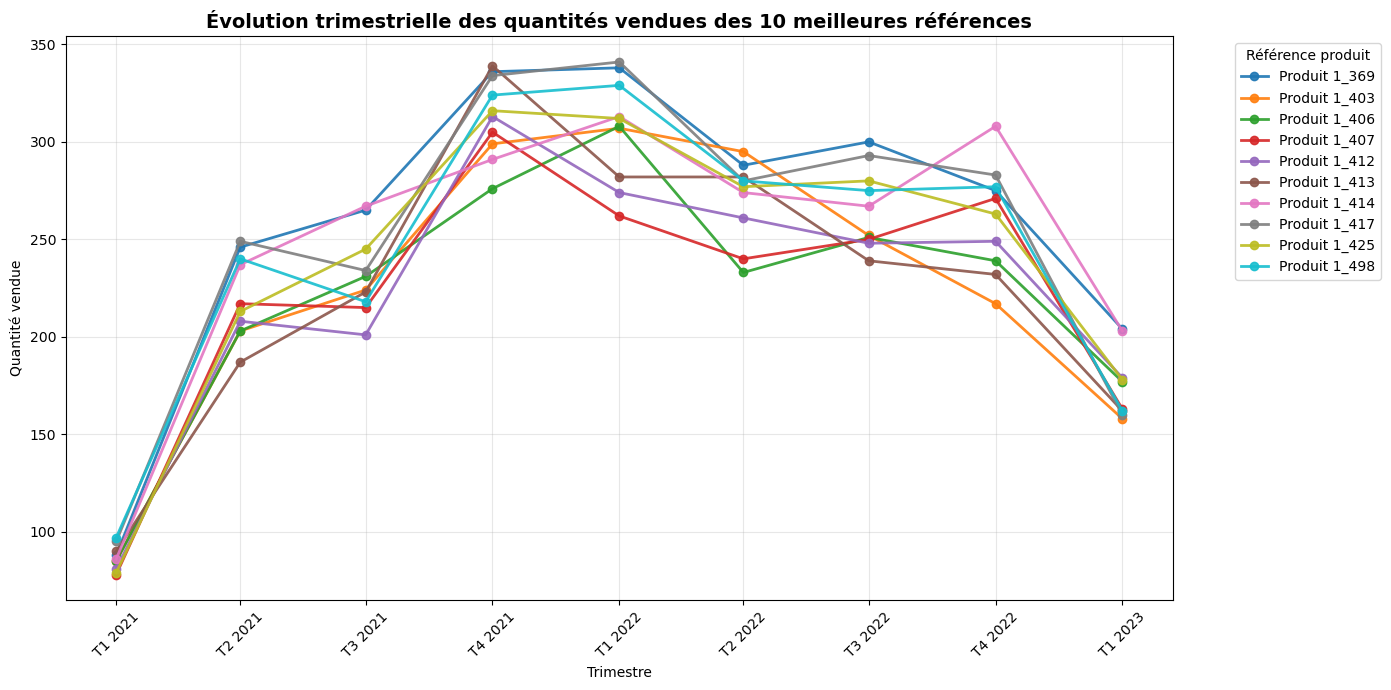

In [33]:
# Identifier les 10 produits les plus vendus
top10_produits_qte = df.groupby('id_prod')['id_prod'].count().nlargest(10).index

# Calculer les quantités vendues par trimestre pour ces livres
qte_top10_trim = (
    df[df['id_prod'].isin(top10_produits_qte)]
    .groupby([df['date'].dt.to_period('Q'), 'id_prod'])['id_prod']
    .count()
    .unstack(fill_value=0)
)

# Créer les labels trimestre-année
labels_trim = [f"T{d.quarter} {d.year}" for d in qte_top10_trim.index.to_timestamp()]

# Tracer les courbes
plt.figure(figsize=(14,7))
palette = sns.color_palette("tab10", n_colors=10)  

for i, col in enumerate(qte_top10_trim.columns):
    plt.plot(
        qte_top10_trim.index.to_timestamp(),
        qte_top10_trim[col],
        label=f"Produit {col}",
        color=palette[i],
        linewidth=2,
        alpha=0.9,
        marker='o'
    )

# Mise en forme 
plt.title("Évolution trimestrielle des quantités vendues des 10 meilleures références", fontsize=14, fontweight='bold')
plt.xlabel("Trimestre")
plt.ylabel("Quantité vendue")
plt.xticks(qte_top10_trim.index.to_timestamp(), labels_trim, rotation=45)
plt.legend(title="Référence produit", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("evol_tps_qt_top10.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

### Analyse des clients 

#### Les 20 meilleurs clients rapportant le plus de CA

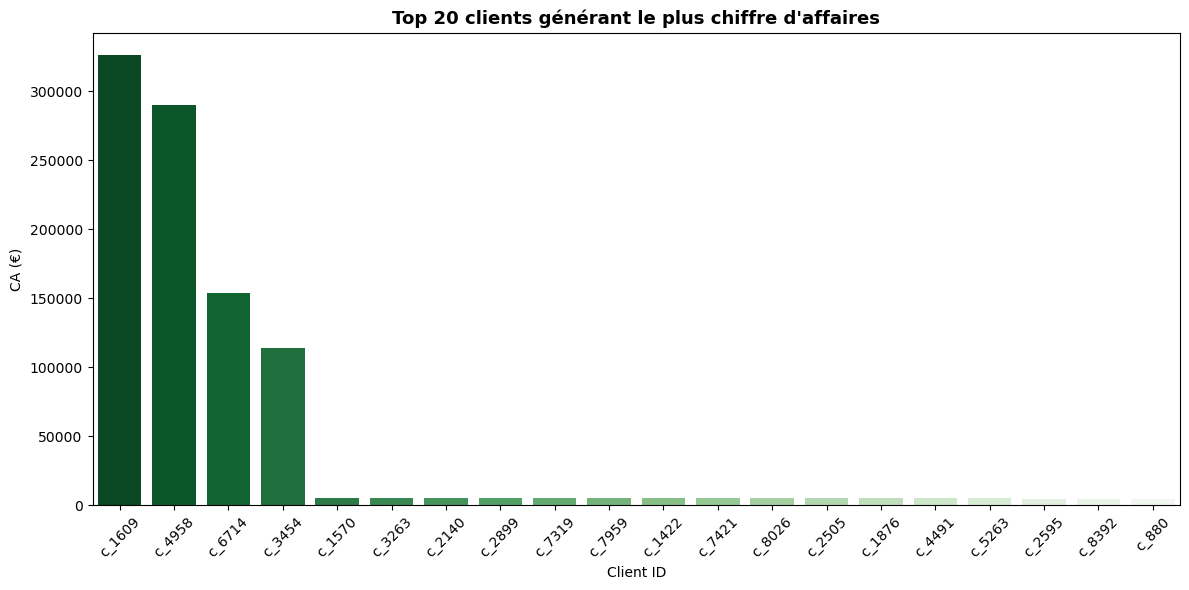

In [34]:
# CA total par client 
ca_clients = df.groupby('client_id')['price'].sum().sort_values(ascending=False).head(20)
#visualisation
plt.figure(figsize=(12,6))
sns.barplot(x=ca_clients.index, y=ca_clients.values, palette='Greens_r', hue= ca_clients.index)
plt.title("Top 20 clients générant le plus chiffre d'affaires", fontsize=13, fontweight='bold')
plt.xlabel("Client ID")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top20_clt_ca.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#### TOP 20 meilleurs clients sans les 4 extrêmes

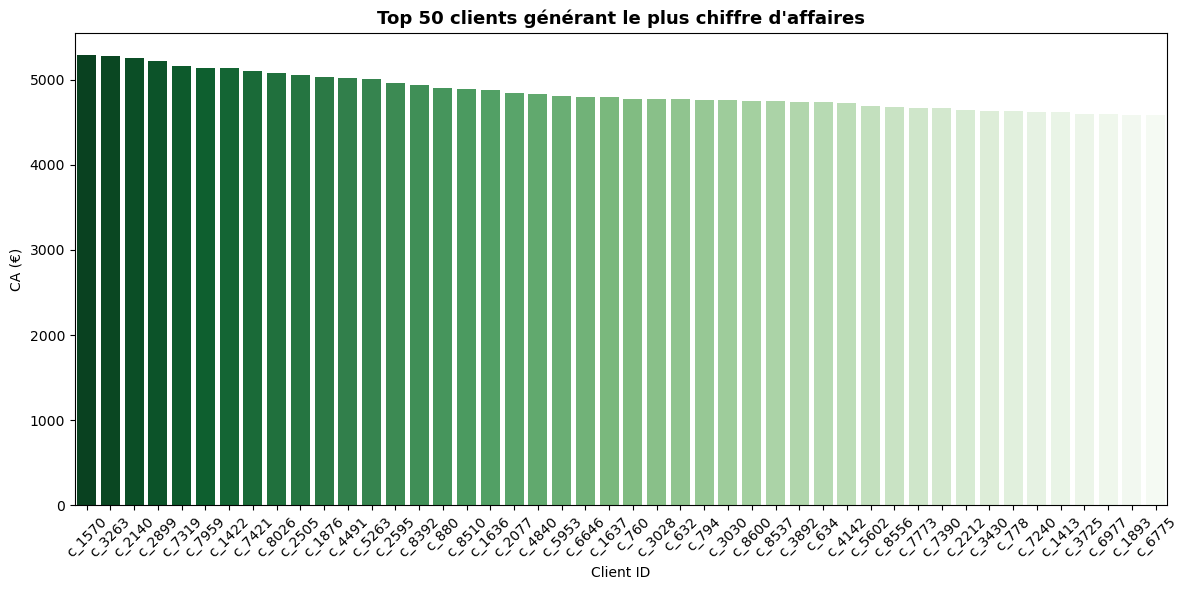

In [35]:
# CA total par client 
ca_clients = df.groupby('client_id')['price'].sum().sort_values(ascending=False).head(50)
#visualisation
plt.figure(figsize=(12,6))
sns.barplot(x=ca_clients.index[4:], y=ca_clients.values[4:], palette='Greens_r', hue= ca_clients.index[4:])
plt.title("Top 50 clients générant le plus chiffre d'affaires", fontsize=13, fontweight='bold')
plt.xlabel("Client ID")
plt.ylabel("CA (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top50_clt_ca_ss_ext.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

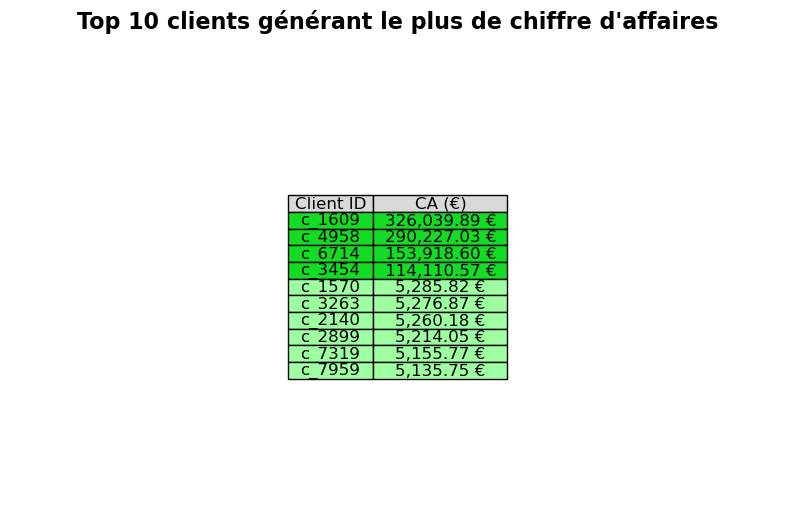

In [36]:
# Top 10 clients par CA
top_clients_df = df.groupby('client_id')['price'].sum().sort_values(ascending=False).head(10).reset_index()
top_clients_df.columns = ['Client ID', 'CA (€)']

# Arrondir le CA avec 2 décimales
top_clients_df['CA (€)'] = top_clients_df['CA (€)'].map(lambda x: f"{x:,.2f} €")

# Créer la figure
fig, ax = plt.subplots(figsize=(10,6))
ax.axis('off')  # On n'affiche pas les axes

# Définir les couleurs : 4 verts foncés, 6 verts clairs
colors = ['#14db24']*4 + ['#9effa1']*6  

# Créer le tableau
table = ax.table(
    cellText=top_clients_df.values,
    colLabels=top_clients_df.columns,
    cellColours=[[colors[i], colors[i]] for i in range(len(colors))],
    colColours=['#d9d9d9','#d9d9d9'],
    loc='center',
    cellLoc='center'
)

# Ajuster la taille de police et les colonnes
table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width([0,1])

# Ajouter un titre
plt.title("Top 10 clients générant le plus de chiffre d'affaires", fontsize=16, fontweight='bold', pad=20)
plt.savefig("tab_top10_cli_ca.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#### Courbe de Lorenz

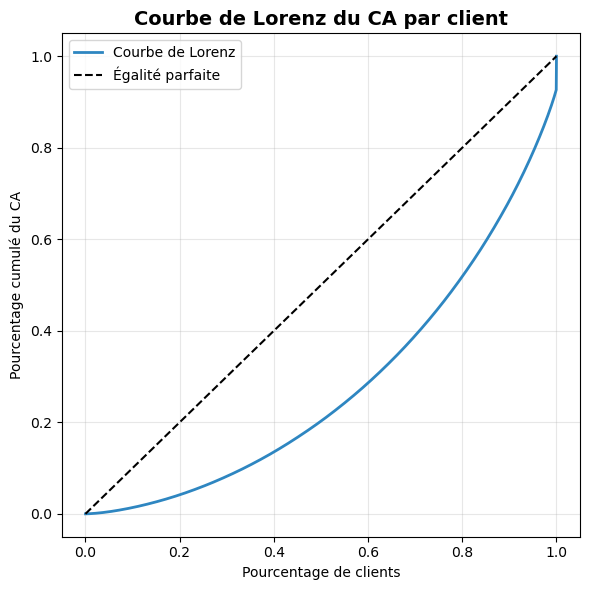

Indice de Gini : 0.442


In [37]:
#Calcul du CA par client
ca_clients = df.groupby('client_id')['price'].sum().sort_values()

#Normaliser pour la courbe de Lorenz
ca_cum = np.cumsum(ca_clients)  
ca_cum = ca_cum / ca_cum.iloc[-1]   

#Pourcentage de clients
clients_perc = np.arange(1, len(ca_clients)+1) / len(ca_clients)

#Tracer la courbe de Lorenz
plt.figure(figsize=(6,6))
plt.plot(clients_perc, ca_cum, color='#2E86C1', linewidth=2, label='Courbe de Lorenz')
plt.plot([0,1], [0,1], color='k', linestyle='--', label='Égalité parfaite')

plt.title("Courbe de Lorenz du CA par client", fontsize=14, fontweight='bold')
plt.xlabel("Pourcentage de clients")
plt.ylabel("Pourcentage cumulé du CA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("courbe_lorenz.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Calcul de l'indice de Gini
Gini = 1 - 2 * np.trapz(ca_cum, clients_perc)
print(f"Indice de Gini : {Gini:.3f}")

#### Panier moyen par tranche d'age

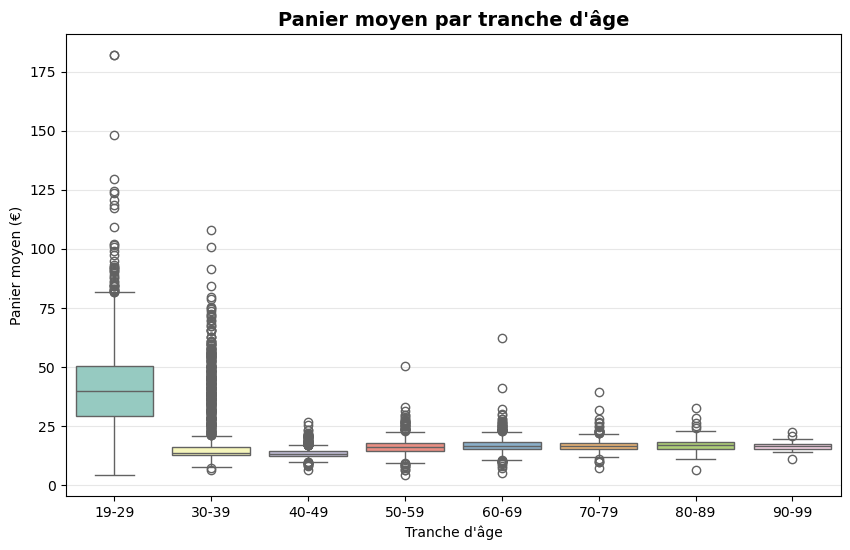

In [38]:
#Calcul du panier moyen par client
panier_client = df.groupby('client_id').agg(
    total_achat=('price','sum'),
    n_achats=('price','count'),
    tranche_age=('tranche_age','first')  # récupère la tranche d'âge du client
).reset_index()

panier_client['panier_moyen'] = panier_client['total_achat'] / panier_client['n_achats']

plt.figure(figsize=(10,6))
sns.boxplot(data=panier_client, x='tranche_age', y='panier_moyen', palette='Set3', hue='tranche_age')
plt.title("Panier moyen par tranche d'âge", fontsize=14, fontweight='bold')
plt.xlabel("Tranche d'âge")
plt.ylabel("Panier moyen (€)")
plt.grid(axis='y', alpha=0.3)
plt.savefig("pm_tranche_age.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

#### CA par tranche d'age 

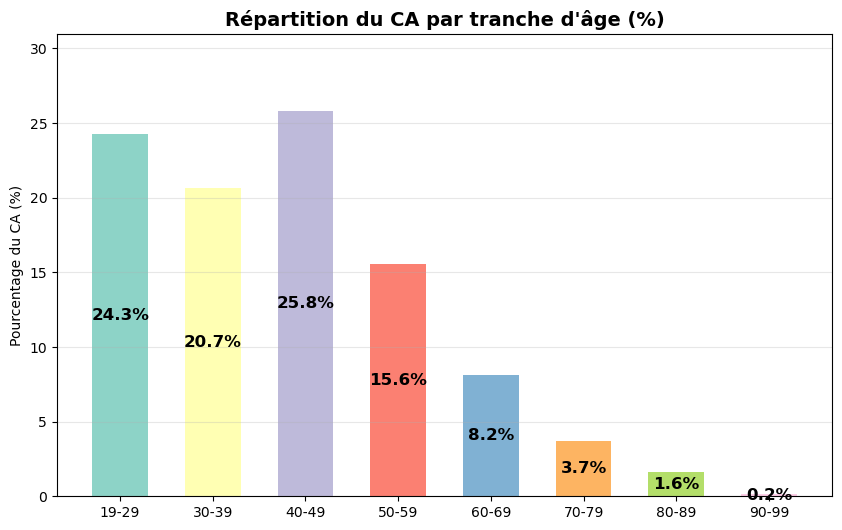

In [39]:
# CA total par tranche d'âge en pourcentage
ca_tranche = df.groupby('tranche_age', observed=True)['price'].sum().sort_index()
ca_tranche_pct = ca_tranche / ca_tranche.sum() * 100

# Couleurs palette Set2 
colors = sns.color_palette("Set3", n_colors=len(ca_tranche_pct))

plt.figure(figsize=(10,6))

# Barres + larges pour y inserer les pourcentages
ax = plt.bar(ca_tranche_pct.index, ca_tranche_pct.values, color=colors, width=0.6)

plt.title("Répartition du CA par tranche d'âge (%)", fontsize=14, fontweight='bold')
plt.ylabel("Pourcentage du CA (%)")
plt.ylim(0, ca_tranche_pct.max() * 1.2)  

# Ajouter les pourcentages à l'intérieur des barres
for i, v in enumerate(ca_tranche_pct.values):
    plt.text(i, v/2, f"{v:.1f}%", ha='center', va='center', color='black', fontweight='bold', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.savefig("ca_trage.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## PARTIE 2: Analyse ciblée des clients

In [40]:
# CA total par client
ca_clients_total = df.groupby('client_id')['price'].sum()

# Calculer seuil des outliers (ex: 1.5*IQR)
Q1 = ca_clients_total.quantile(0.25)
Q3 = ca_clients_total.quantile(0.75)
IQR = Q3 - Q1
seuil = Q3 + 1.5*IQR

outliers = ca_clients_total[ca_clients_total > seuil]
print(outliers.info())
print(outliers.sort_values(ascending=False))

<class 'pandas.core.series.Series'>
Index: 251 entries, c_1006 to c_963
Series name: price
Non-Null Count  Dtype  
--------------  -----  
251 non-null    float64
dtypes: float64(1)
memory usage: 3.9 KB
None
client_id
c_1609    326039.89
c_4958    290227.03
c_6714    153918.60
c_3454    114110.57
c_1570      5285.82
            ...    
c_7245      3659.80
c_383       3656.99
c_8199      3655.61
c_3899      3654.40
c_4182      3653.22
Name: price, Length: 251, dtype: float64


In [41]:
# Identifier les 4 clients extrêmes
ca_clients = df.groupby('client_id')['price'].sum().reset_index()
extremes = ca_clients.nlargest(4, 'price')['client_id']

# Créer un DataFrame sans ces 4 clients
df_clean = df[~df['client_id'].isin(extremes)]

In [42]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 640734 entries, 0 to 687533
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id_prod      640734 non-null  string        
 1   date         640734 non-null  datetime64[ns]
 2   client_id    640734 non-null  string        
 3   price        640734 non-null  float64       
 4   categ        640734 non-null  category      
 5   sex          640734 non-null  category      
 6   age          640734 non-null  int64         
 7   tranche_age  640734 non-null  category      
dtypes: category(3), datetime64[ns](1), float64(1), int64(1), string(2)
memory usage: 31.2 MB
None


### 1ere correlation: lien entre le genre d'un client et les catégories de livres achetés

In [43]:
# On construit un tableau de contingence
table = pd.crosstab(df_clean['sex'], df_clean['categ'])
print("Tableau de contingence :")
print(table)

# Test du Chi²
chi2, p, dof, expected = chi2_contingency(table)
print(f"\nStatistique du chi² : {chi2:.2f}")
print(f"Degrés de liberté : {dof}")
print(f"p-value : {p:.4f}")

# Interprétation
alpha = 0.05
if p < alpha:
    print("Il existe une relation significative entre le genre et la catégorie de livres achetés.")
else:
    print("Aucune relation significative détectée entre le genre et la catégorie de livres.")

# pour déterminer la 'force' du lien: v de cramer
n = table.sum().sum()  # nombre total d'observations
phi2 = chi2 / n
r, k = table.shape
cramers_v = np.sqrt(phi2 / min(k-1, r-1))

print(f"V de Cramer = {cramers_v:.3f}")

Tableau de contingence :
categ       0       1      2
sex                         
f      200793  115721  16980
m      186488  104884  15868

Statistique du chi² : 22.67
Degrés de liberté : 2
p-value : 0.0000
Il existe une relation significative entre le genre et la catégorie de livres achetés.
V de Cramer = 0.006


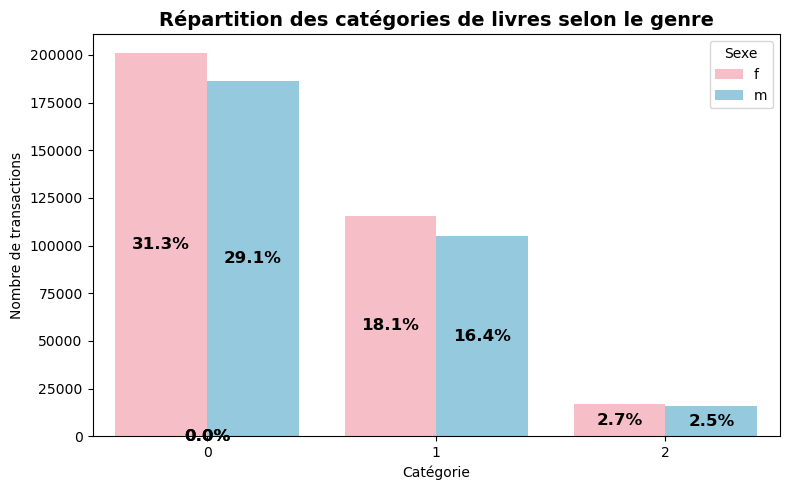

In [44]:
#simple représentation
palette_custom = {'m': 'skyblue', 'f': 'lightpink'}

# Comptage total pour calculer les pourcentages
total = len(df_clean)

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_clean, x='categ', hue='sex', palette=palette_custom)

# Ajouter les pourcentages sur les barres
for p in ax.patches:
    height = p.get_height()
    percent = height / total * 100
    ax.text(
        p.get_x() + p.get_width()/2,  
        height / 2,                   
        f"{percent:.1f}%",            
        ha='center',
        va='center',
        color='black',
        fontweight='bold',
        fontsize=12
    )

plt.title("Répartition des catégories de livres selon le genre", fontsize=14, fontweight='bold')
plt.xlabel("Catégorie")
plt.ylabel("Nombre de transactions")
plt.legend(title='Sexe')
plt.tight_layout()
plt.savefig("corr_genre_categ.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

### 2e correlation: lien entre l'age des clients et le montant total des achats

Spearman: corr=-0.18, p-value=0.0000
La corrélation de Spearman est significative : il existe une relation monotone entre l’âge et le total des achats.


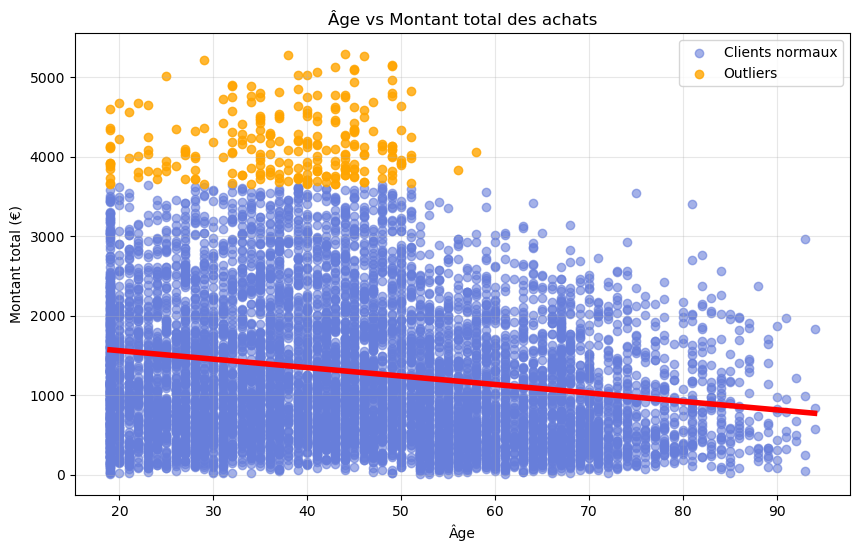

In [45]:
# Total des achats et âge par client 
ca_client = df_clean.groupby('client_id').agg(
    total_achat=('price', 'sum'),
    age=('age', 'first')
).reset_index()

# Corrélations
corr_spearman, p_spearman = spearmanr(ca_client['age'], ca_client['total_achat'])
print(f"Spearman: corr={corr_spearman:.2f}, p-value={p_spearman:.4f}")

# Interprétation statistique
alpha = 0.05
if p_spearman < alpha:
    print("La corrélation de Spearman est significative : il existe une relation monotone entre l’âge et le total des achats.")
else:
    print("Aucune corrélation monotone significative détectée entre l’âge et le total des achats.")


#Identification des outliers
Q1 = ca_client['total_achat'].quantile(0.25)
Q3 = ca_client['total_achat'].quantile(0.75)
IQR = Q3 - Q1
seuil_outlier = Q3 + 1.5 * IQR

outliers = ca_client[ca_client['total_achat'] > seuil_outlier]
normaux = ca_client[ca_client['total_achat'] <= seuil_outlier]


plt.figure(figsize=(10,6))
# Clients normaux
plt.scatter(normaux['age'], normaux['total_achat'], 
            alpha=0.6, label='Clients normaux', color='#677EDA')
# Outliers restants
plt.scatter(outliers['age'], outliers['total_achat'], 
            alpha=0.8, label='Outliers', color='orange')

# Ligne de régression 
sns.regplot(data=ca_client, x='age', y='total_achat', 
            scatter=False, color='red', ci=None, 
            line_kws={'color':'red', 'linewidth':4})

plt.title("Âge vs Montant total des achats")
plt.xlabel("Âge")
plt.ylabel("Montant total (€)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("corr_age_montant.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

### 3e correlation: l'age des clients et la fréquence d'achat

Spearman: corr=0.13, p-value=0.0000
La corrélation de Spearman est significative : il existe une relation monotone entre l’âge et le total des achats.


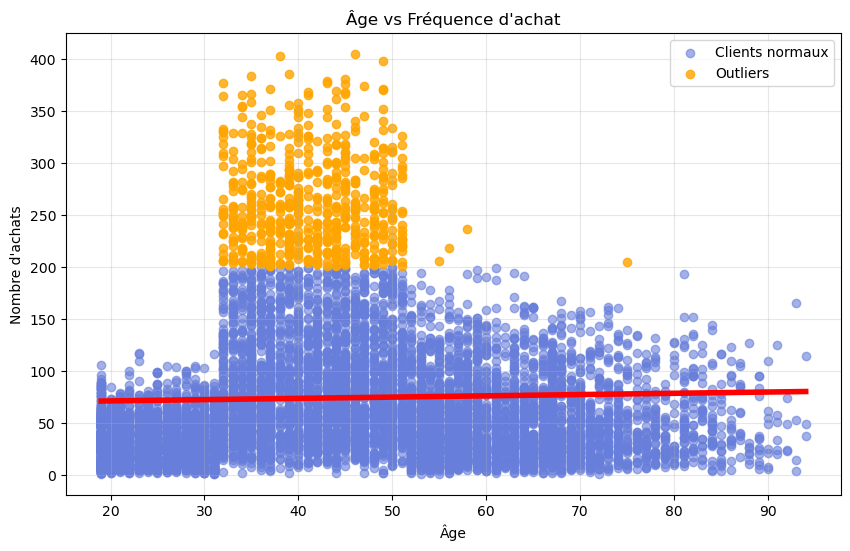

In [46]:
# Nombre d'achats par client et âge 
freq_client = df_clean.groupby('client_id').agg(
    n_achats=('id_prod', 'count'),
    age=('age', 'first')
).reset_index()

# Corrélations
corr_spearman, p_spearman = spearmanr(freq_client['age'], freq_client['n_achats'])
print(f"Spearman: corr={corr_spearman:.2f}, p-value={p_spearman:.4f}")

# Interprétation statistique
alpha = 0.05
if p_spearman < alpha:
    print("La corrélation de Spearman est significative : il existe une relation monotone entre l’âge et le total des achats.")
else:
    print("Aucune corrélation monotone significative détectée entre l’âge et le total des achats.")


#Identification des outliers 
Q1 = freq_client['n_achats'].quantile(0.25)
Q3 = freq_client['n_achats'].quantile(0.75)
IQR = Q3 - Q1
seuil_outlier = Q3 + 1.5 * IQR

outliers = freq_client[freq_client['n_achats'] > seuil_outlier]
normaux = freq_client[freq_client['n_achats'] <= seuil_outlier]

plt.figure(figsize=(10,6))
# Clients normaux
plt.scatter(normaux['age'], normaux['n_achats'], 
            alpha=0.6, label='Clients normaux', color='#677EDA')
# Outliers restants
plt.scatter(outliers['age'], outliers['n_achats'], 
            alpha=0.8, label='Outliers', color='orange')

# Ligne de régression
sns.regplot(data=freq_client, x='age', y='n_achats', 
            scatter=False, color='red', ci=None, 
            line_kws={'color':'red', 'linewidth':4})

plt.title("Âge vs Fréquence d'achat")
plt.xlabel("Âge")
plt.ylabel("Nombre d'achats")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("corr_age_freq.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

### 4e correlation: lien  entre l'age des clients et la taille du panier moyen

Spearman: corr=-0.33, p-value=0.0000
La corrélation de Spearman est significative : il existe une relation monotone entre l’âge et le total des achats.


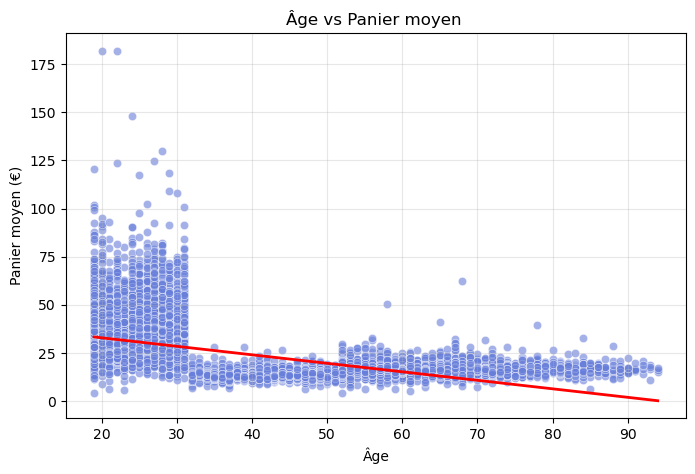

In [47]:
# Panier moyen par client
panier_client = df_clean.groupby('client_id').agg(
    total_achat=('price','sum'),
    n_achats=('price','count'),
    age=('age','first')
).reset_index()

panier_client['panier_moyen'] = panier_client['total_achat'] / panier_client['n_achats']

# Spearman
corr_spearman, p_spearman = spearmanr(panier_client['age'], panier_client['panier_moyen'])
print(f"Spearman: corr={corr_spearman:.2f}, p-value={p_spearman:.4f}")

# Interprétation statistique
alpha = 0.05
if p_spearman < alpha:
    print("La corrélation de Spearman est significative : il existe une relation monotone entre l’âge et le total des achats.")
else:
    print("Aucune corrélation monotone significative détectée entre l’âge et le total des achats.")


plt.figure(figsize=(8,5))
sns.scatterplot(data=panier_client, x='age', y='panier_moyen', alpha=0.6, color='#677EDA')

sns.regplot(
    data=panier_client, 
    x='age', 
    y='panier_moyen', 
    scatter=False, 
    color='red', 
    line_kws={'linewidth':2}, 
    ci=None
)
plt.title("Âge vs Panier moyen ")
plt.xlabel("Âge")
plt.ylabel("Panier moyen (€)")
plt.grid(alpha=0.3)
plt.savefig("corr_age_pm.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()

Nombre d'outliers : 1433
Spearman: corr=-0.33, p-value=0.0000
Corrélation de Spearman significative : relation monotone détectée.


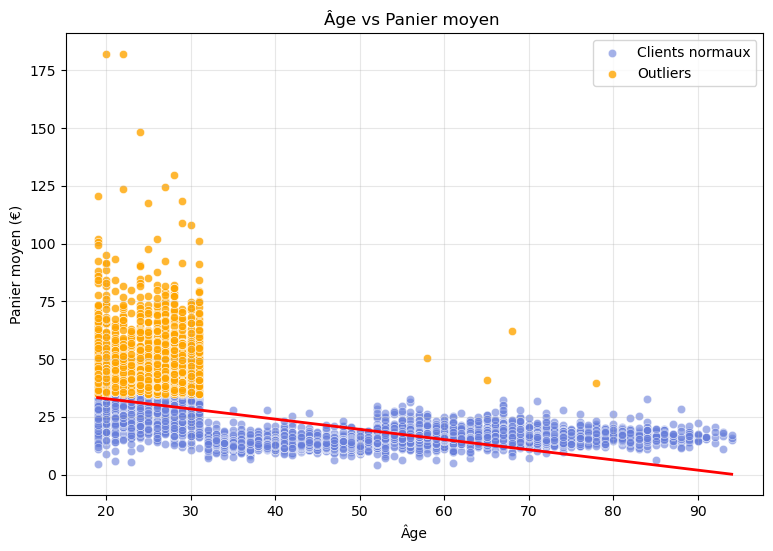

In [48]:
# Panier moyen par client
panier_client = df_clean.groupby('client_id').agg(
    total_achat=('price', 'sum'),
    n_achats=('price', 'count'),
    age=('age', 'first')
).reset_index()

panier_client['panier_moyen'] = panier_client['total_achat'] / panier_client['n_achats']


# Détection des outliers 
Q1 = panier_client['panier_moyen'].quantile(0.25)
Q3 = panier_client['panier_moyen'].quantile(0.75)
IQR = Q3 - Q1
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

# points normaux
normal = panier_client[
    (panier_client['panier_moyen'] >= borne_inf) &
    (panier_client['panier_moyen'] <= borne_sup)
]

# outliers
outliers = panier_client[
    (panier_client['panier_moyen'] < borne_inf) |
    (panier_client['panier_moyen'] > borne_sup)
]

print(f"Nombre d'outliers : {len(outliers)}")



# Spearman sur TOUTES les données (avec outliers)
corr_spearman, p_spearman = spearmanr(
    panier_client['age'],
    panier_client['panier_moyen']
)
print(f"Spearman: corr={corr_spearman:.2f}, p-value={p_spearman:.4f}")

alpha = 0.05
if p_spearman < alpha:
    print("Corrélation de Spearman significative : relation monotone détectée.")
else:
    print("Aucune corrélation monotone significative détectée.")

# Visualisation 
plt.figure(figsize=(9, 6))
#Points clients normaux
sns.scatterplot(
    data=normal,
    x='age',
    y='panier_moyen',
    color='#677EDA',
    alpha=0.6,
    label='Clients normaux'
)
#Points outliers
sns.scatterplot(
    data=outliers,
    x='age',
    y='panier_moyen',
    color='orange',
    alpha=0.8,
    label='Outliers'
)
# Ligne de tendance 
sns.regplot(
    data=panier_client,
    x='age',
    y='panier_moyen',
    scatter=False,
    color='red',
    line_kws={'linewidth': 2},
    ci=None
)

plt.title("Âge vs Panier moyen ")
plt.xlabel("Âge")
plt.ylabel("Panier moyen (€)")
plt.grid(alpha=0.3)
plt.legend()

plt.savefig("corr_age_pm_outliers.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()


### 5e correlation : lien entre l'age des clients et la catégorie de livres achetes

ANOVA : F=39705.52, p-value=0.0000


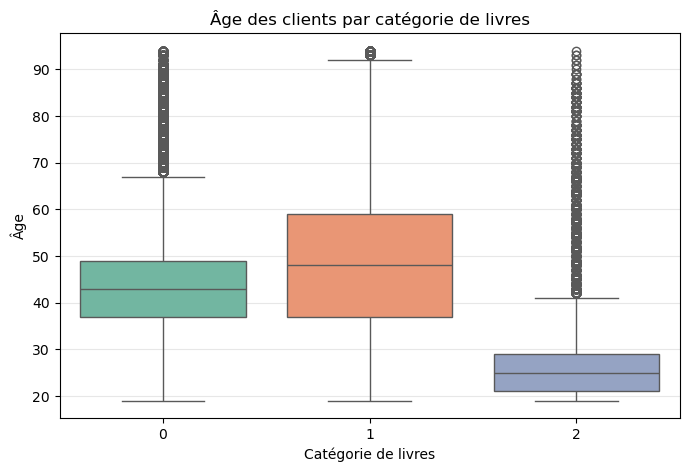

In [49]:
# Créer une liste des âges par catégorie
groupes = [df_clean[df_clean['categ']==c]['age'] for c in df_clean['categ'].unique()]

# ANOVA
f_val, p_val = f_oneway(*groupes)
print(f"ANOVA : F={f_val:.2f}, p-value={p_val:.4f}")

plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='categ', y='age', palette='Set2', hue='categ')
plt.title("Âge des clients par catégorie de livres")
plt.xlabel("Catégorie de livres")
plt.ylabel("Âge")
plt.grid(axis='y', alpha=0.3)
plt.savefig("corr_age_categ.jpg", format='jpg', dpi=300, bbox_inches='tight')
plt.show()